# Observation Model

The `observe()` function takes Covasim’s simulated infection results (`new_infections`) and generates **observed diagnoses** and **observed sequencing counts**.  

## How the Function Works

### 1) Load true infections from Covasim
- `sim.results['new_infections']` provides the number of actual infections per day.
- This represents the “true epidemic curve” before any observation or reporting bias.

### 2) Initialize arrays for observed data
- `new_diag`: daily observed diagnoses  
- `new_seq`: daily observed sequences  
Both start at zero and are filled through probabilistic sampling.

### 3) Sample who gets tested
For each day:
- Let `n` be the number of new infections.
- A fraction `p_test` of infected individuals receive a diagnostic test.
- This is modeled using a binomial draw:  
  `n_diag ~ Binomial(n, p_test)`.

### 4) Apply reporting delay
- Diagnosed individuals are distributed across future days according to `delay_pmf`.
- This uses a multinomial draw:  
  `diag_by_delay ~ Multinomial(n_diag, delay_pmf)`.
- Example: if `delay_pmf = [0.05, 0.15, 0.30, ...]`, then  
  5% are diagnosed on the same day,  
  15% after 1 day,  
  30% after 2 days, etc.

### 5) Ignore diagnoses that fall outside the simulation window
- If `day + k >= T`, those diagnoses are dropped.

### 6) Sample sequencing among diagnosed individuals
- For each diagnosis count on a given day,  
  `seq ~ Binomial(count, p_seq)`  
  determines how many are sequenced.

### 7) Compute and print cumulative totals
- `np.cumsum(new_diag)[-1]` → total observed diagnoses  
- `np.cumsum(new_seq)[-1]` → total observed sequences  

These provide a quick summary of the observation model output.

## How This Differs from Covasim’s Diagnosis Logic

Covasim’s diagnosis system works at the individual (agent) level. Each person has symptoms, testing behavior, test sensitivity, and a built‑in test delay. Symptomatic and asymptomatic people have different testing probabilities, and interventions like isolation or contact tracing can change who gets tested and when results appear.

In contrast, the `observe()` function is a simplified, aggregate‑level observation model. It does not track individuals. Instead, it takes daily infection counts and applies a single testing probability, a user‑defined delay distribution, and a fixed sequencing probability. It ignores symptoms, test sensitivity, and agent‑level behavior.

In short: Covasim models how diagnoses actually happen, while `observe()` models how many of those infections would be observed after under‑reporting and delays.


In [3]:
import sys
sys.path.append("/home/jhkim/covasim_project/jhk_covasim4wastewater")

Initializing sim with 20000 people for 60 days
  Running 2020-03-01 ( 0/60) (0.24 s)  ———————————————————— 2%
  Running 2020-03-11 (10/60) (0.30 s)  •••————————————————— 18%
  Running 2020-03-21 (20/60) (0.38 s)  ••••••—————————————— 34%
  Running 2020-03-31 (30/60) (0.44 s)  ••••••••••—————————— 51%
  Running 2020-04-10 (40/60) (0.51 s)  •••••••••••••——————— 67%
  Running 2020-04-20 (50/60) (0.58 s)  ••••••••••••••••———— 84%
  Running 2020-04-30 (60/60) (0.66 s)  •••••••••••••••••••• 100%

Simulation summary:
        1,503 cumulative infections
           17 cumulative reinfections
        1,183 cumulative infectious
          731 cumulative symptomatic cases
           47 cumulative severe cases
           15 cumulative critical cases
          706 cumulative recoveries
            4 cumulative deaths
          685 cumulative tests
          685 cumulative diagnoses
            4 cumulative known deaths
            0 cumulative quarantined people
          685 cumulative isolated peo

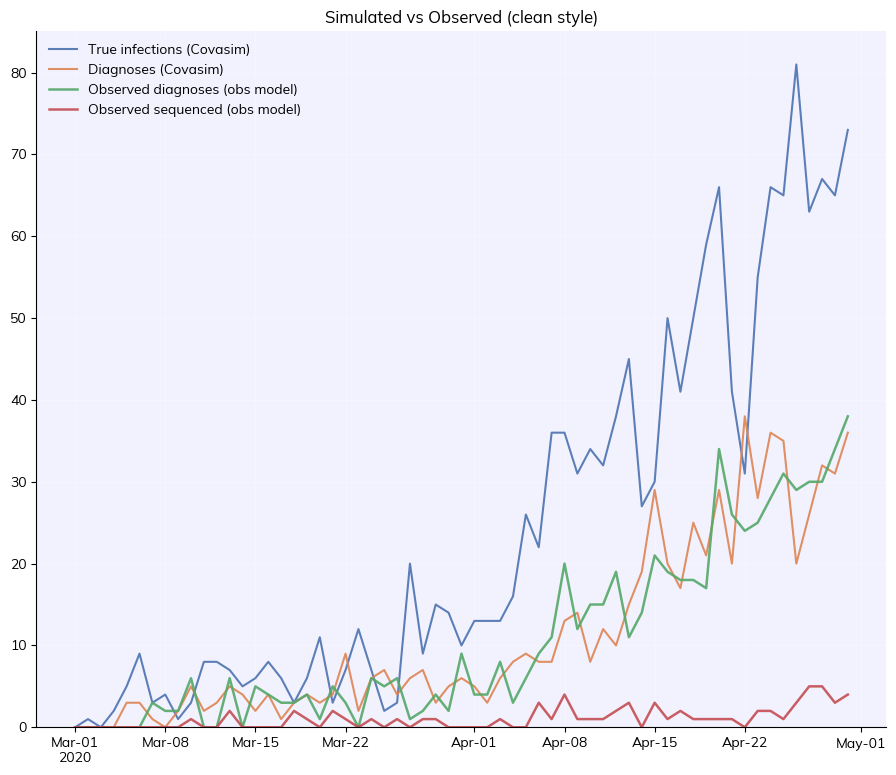

In [4]:
import covasim as cv
import numpy as np
from observation_model import observe, plot_sim_vs_observed

p_test = 0.5
p_seq = 0.1

interv = cv.test_prob(symp_prob=p_test)
sim = cv.Sim(interventions=[interv])
sim.run()

new_diag, new_seq = observe(sim, p_test, p_seq, [0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03])

plot_sim_vs_observed(sim, new_diag, new_seq)

When we set Covasim’s symptomatic testing probability (symp_prob) to 0.5 and, in parallel, configured the observation model with the same testing probability (p_test = 0.5), we observe that the two diagnosis curves show very similar trends.